In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("experiments/viz/results_judged_original_lang.csv")

In [ ]:
filtered_df = df[
    ["orig_lang_pred_score", "gemma_pred_score", "model", "lang_code"]
].copy()
filtered_df = filtered_df.rename(
    columns={
        "orig_lang_pred_score": "english_judge",
        "gemma_pred_score": "original_lang_judge",
    }
)
filtered_df["model"] = filtered_df["model"].replace(
    "GPT-3.5 Turbo 0125", "GPT-3.5 Turbo"
)
filtered_df["model"] = filtered_df["model"].replace(
    "DeepSeek Chat V3 0324", "DeepSeek V3"
)

filtered_df.head()

,english_judge,original_lang_judge,model,lang_code
0,4,4.0,DeepSeek V3,zu
1,2,2.0,DeepSeek V3,zu
2,4,4.0,DeepSeek V3,zu
3,2,2.0,DeepSeek V3,zu
4,4,4.0,DeepSeek V3,zu


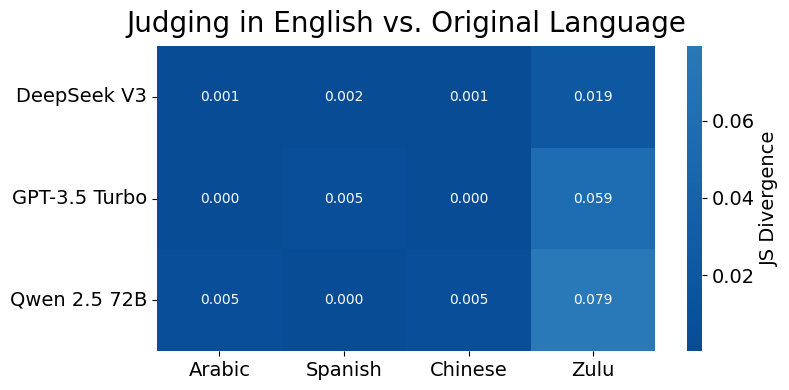

In [ ]:
from scipy.spatial.distance import jensenshannon
import matplotlib.colors as mcolors


# Function to calculate JS divergence between two distributions
def js_divergence(p, q):
    # Convert to probability distributions
    p_counts = np.bincount(p.astype(int), minlength=6)[1:6]  # scores 1-5
    q_counts = np.bincount(q.astype(int), minlength=6)[1:6]  # scores 1-5

    # Normalize to probabilities (add small epsilon to avoid log(0))
    epsilon = 1e-10
    p_prob = (p_counts + epsilon) / (p_counts.sum() + 5 * epsilon)
    q_prob = (q_counts + epsilon) / (q_counts.sum() + 5 * epsilon)

    return jensenshannon(p_prob, q_prob) ** 2


# Create a pivot table for the JS divergence between english_judge and original_lang_judge
js_data = (
    filtered_df.dropna()
    .groupby(["model", "lang_code"])
    .apply(
        lambda x: js_divergence(x["english_judge"], x["original_lang_judge"]),
        include_groups=False,
    )
    .reset_index(name="js_divergence")
)

# Pivot the data for heatmap
heatmap_data = js_data.pivot(index="model", columns="lang_code", values="js_divergence")

# Replace language codes with full names
lang_code_mapping = {"ar": "Arabic", "es": "Spanish", "zh-cn": "Chinese", "zu": "Zulu"}

heatmap_data = heatmap_data.rename(columns=lang_code_mapping)

# Create the heatmap
fig, ax = plt.subplots(figsize=(8, 4))

# Use only 10-100% of the Blues palette (skips the darkest blues)
cmap = mcolors.LinearSegmentedColormap.from_list(
    "lighter_blues", sns.color_palette("Blues_r", n_colors=100)[10:]
)

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap=cmap,
    center=0.2,  # vmin=-0.01,,
    cbar_kws={"label": "JS Divergence"},
    fmt=".3f",
    ax=ax,
)
ax.tick_params(axis="y", rotation=0, labelsize=14)
ax.tick_params(axis="x", rotation=0, labelsize=14)
ax.set_title("Judging in English vs. Original Language", fontsize=20, pad=10)
ax.set_xlabel("")
ax.set_ylabel("")
# Increase colorbar label fontsize
# Manually set the colorbar limits and ticks
cbar = ax.collections[0].colorbar
# cbar.mappable.set_clim(0, 0.3)
# cbar.set_ticks(np.linspace(0, 0.3, 4))
cbar.ax.tick_params(labelsize=14)
cbar.set_label("JS Divergence", fontsize=14)

plt.tight_layout()

fig.savefig(
    "data/figures_new/english_vs_original_judge.pdf", format="pdf", bbox_inches="tight"
)

plt.show()